## Imports

In [144]:
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from collections import defaultdict
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict
from torch.utils.data import Dataset
import torch
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns


## DATA STRUCTURES FOR RESNET DATASET


In [4]:
@dataclass
class CropSample:
    """
    Represents a single crop sample for ResNet training.
    
    Attributes:
        image_path: Path to the original source image
        bbox: Bounding box coordinates (x1, y1, x2, y2)
        category_id: Category ID (0-4) for first stage classification
        sign_class: Specific sign class (0-54) or -1 for background
        is_background: Flag indicating if this is a background/negative sample
    """
    image_path: Path
    bbox: Tuple[int, int, int, int]
    category_id: int
    sign_class: int  # -1 for background
    is_background: bool


@dataclass
class CategoryDataset:
    """
    Dataset for a single ResNet category.
    
    Attributes:
        category_id: Category ID (0-4)
        samples: List of crop samples belonging to this category
    """
    category_id: int
    samples: List[CropSample]


## IOU CALCULATION


In [6]:
def iou(box1: List[int], box2: List[int]) -> float:
    """
    Calculate Intersection over Union (IoU) between two bounding boxes.
    
    Args:
        box1: First bounding box [x1, y1, x2, y2]
        box2: Second bounding box [x1, y1, x2, y2]
    
    Returns:
        IoU value between 0 and 1
    """
    # Calculate intersection coordinates
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    # Calculate intersection area
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Calculate union area
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0


def count_boxes(label_dir):
    label_dir = Path(label_dir)
    total = 0
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, 'r') as f:
            total += len(f.readlines())
    return total


## COLLECT RANDOM BACKGROUND CROPS

In [8]:
def collect_random_background_crops(
    image_dir: str,
    ground_truths_map: Dict[str, List[dict]],
    num_per_image: int = 5,
    crop_size: tuple = (100, 100)
) -> List[CropSample]:
    """
    Collect random background crops from areas without signs.
    
    Args:
        image_dir: Directory containing images
        ground_truths_map: Mapping from image name to ground truth boxes
        num_per_image: Number of random crops per image
        crop_size: Size of random crops (width, height)
    
    Returns:
        List of background CropSample objects
    """
    random_bg_samples = []
    
    for img_path in Path(image_dir).glob("*.jpg"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
            
        h, w = img.shape[:2]
        
        # Get ground truths for this image
        gts = ground_truths_map.get(img_path.stem, [])
        
        for _ in range(num_per_image):
            # Generate random position
            x1 = random.randint(0, max(1, w - crop_size[0]))
            y1 = random.randint(0, max(1, h - crop_size[1]))
            x2 = x1 + crop_size[0]
            y2 = y1 + crop_size[1]
            random_bbox = [x1, y1, x2, y2]
            
            # Check if random crop overlaps with any ground truth sign
            is_overlap = False
            for gt in gts:
                if iou(random_bbox, gt["bbox"]) > 0.1:
                    is_overlap = True
                    break
            
            # If no overlap, add as background for all categories
            if not is_overlap:
                for cat_id in range(5):
                    random_bg_samples.append(
                        CropSample(
                            image_path=img_path,
                            bbox=tuple(random_bbox),
                            category_id=cat_id,
                            sign_class=-1,
                            is_background=True
                        )
                    )
    
    return random_bg_samples

## MAIN DATASET BUILDER


In [10]:
def build_resnet_dataset(
    image_dir: str,
    label_dir: str,
    yolo_model: YOLO,
    sign_to_category: Dict[int, int],  # sign_class -> category_id mapping
    iou_threshold: float = 0.5,
    background_ratio: float = 0.1  # Target background proportion in dataset
) -> Dict[int, CategoryDataset]:
    """
    Build dataset for 5 ResNet models by matching YOLO predictions with ground truth.
    
    This function:
    1. Runs YOLO inference on all images
    2. Matches predictions with ground truth using IoU
    3. Creates positive samples for correct predictions
    4. Creates background samples for false positives and missed signs
    5. Balances the dataset by limiting background samples
    
    Args:
        image_dir: Directory with training images
        label_dir: Directory with YOLO format labels
        yolo_model: Loaded YOLO model
        sign_to_category: Mapping from sign class (0-54) to category (0-4)
        iou_threshold: IoU threshold for matching predictions with ground truth
        background_ratio: Desired proportion of background samples in dataset
    
    Returns:
        Dictionary mapping category_id to CategoryDataset
    """
    
    # Initialize datasets for each category
    category_datasets = {
        cat_id: CategoryDataset(category_id=cat_id, samples=[])
        for cat_id in range(5)
    }
    
    # Track false positives for each category (to use as background)
    false_positives_by_category = defaultdict(list)
    
    # Build ground truth map for random background collection
    ground_truths_map = {}
    
    # Process each image
    for img_path in Path(image_dir).glob("*.jpg"):
        #print(f"Processing: {img_path.name}")
        
        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Warning: Could not read {img_path}")
            continue
            
        h, w = img.shape[:2]
        
        # ============================================================
        # Step 1: Get YOLO predictions
        # ============================================================
        results = yolo_model(img, conf=0.5, verbose=False)
        predictions = []
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                predictions.append({
                    "bbox": [x1, y1, x2, y2],
                    "confidence": float(box.conf[0]),
                    "yolo_category": int(box.cls[0])  # Category from YOLO
                })
        
        # ============================================================
        # Step 2: Read ground truth labels
        # ============================================================
        label_path = Path(label_dir) / (img_path.stem + ".txt")
        ground_truths = []
        
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    
                    
                    sign_class = int(float(parts[0]))  # 0-54
                    x_c, y_c, box_w, box_h = map(float, parts[1:5])
                    
                    # Convert normalized coordinates to pixel coordinates
                    x1 = int((x_c - box_w / 2) * w)
                    y1 = int((y_c - box_h / 2) * h)
                    x2 = int((x_c + box_w / 2) * w)
                    y2 = int((y_c + box_h / 2) * h)
                    
                    ground_truths.append({
                        "bbox": [x1, y1, x2, y2],
                        "sign_class": sign_class,
                        "category_id": sign_to_category[sign_class]
                    })
        
        # Store ground truths for random background collection
        ground_truths_map[img_path.stem] = ground_truths
        
        # ============================================================
        # Step 3: Match predictions with ground truth
        # ============================================================
        matched_gt_indices = set()
        
        for pred in predictions:
            pred_bbox = pred["bbox"]
            best_match_idx = None
            best_iou = 0
            
            for i, gt in enumerate(ground_truths):
                current_iou = iou(pred_bbox, gt["bbox"])
                if current_iou > iou_threshold and current_iou > best_iou:
                    best_iou = current_iou
                    best_match_idx = i
            
            if best_match_idx is not None:
                # TRUE POSITIVE: Add to dataset with correct sign class
                gt = ground_truths[best_match_idx]
                matched_gt_indices.add(best_match_idx)
                
                crop_sample = CropSample(
                    image_path=img_path,
                    bbox=tuple(pred_bbox),
                    category_id=gt["category_id"],
                    sign_class=gt["sign_class"],
                    is_background=False
                )
                category_datasets[gt["category_id"]].samples.append(crop_sample)
                
            else:
                # FALSE POSITIVE: YOLO detected something that isn't there
                # Add as background for the category YOLO predicted
                yolo_category = pred["yolo_category"]
                false_positives_by_category[yolo_category].append(
                    CropSample(
                        image_path=img_path,
                        bbox=tuple(pred_bbox),
                        category_id=yolo_category,
                        sign_class=-1,  # Background
                        is_background=True
                    )
                )
        
        # ============================================================
        # Step 4: Handle false negatives (signs that YOLO missed)
        # ============================================================
        for i, gt in enumerate(ground_truths):
            if i not in matched_gt_indices:
                # YOLO missed this sign - add as background for its category
                false_positives_by_category[gt["category_id"]].append(
                    CropSample(
                        image_path=img_path,
                        bbox=tuple(gt["bbox"]),
                        category_id=gt["category_id"],
                        sign_class=-1,
                        is_background=True
                    )
                )
    
    # ============================================================
    # Step 5: Add random background crops
    # ============================================================
    print("\nCollecting random background crops...")
    random_bg_samples = collect_random_background_crops(
        image_dir, ground_truths_map, num_per_image=5
    )
    
    for cat_id in range(5):
        category_samples = [s for s in random_bg_samples if s.category_id == cat_id]
        category_datasets[cat_id].samples.extend(category_samples)
    
    # ============================================================
    # Step 6: Add false positives to datasets
    # ============================================================
    for cat_id, fp_samples in false_positives_by_category.items():
        # Only add false positives that belong to this category
        category_datasets[cat_id].samples.extend(fp_samples)
    
    # ============================================================
    # Step 7: Balance the dataset (limit background samples)
    # ============================================================
    print("\nDataset statistics after building:")
    
    total_positive = 0
    total_background = 0
    
    for cat_id in range(5):
        dataset = category_datasets[cat_id]
        positive_samples = [s for s in dataset.samples if not s.is_background]
        background_samples = [s for s in dataset.samples if s.is_background]
        
        # Limit background to maintain background_ratio
        if len(positive_samples) > 0:
            max_bg = int(len(positive_samples) * background_ratio / (1 - background_ratio))
            if len(background_samples) > max_bg:
                background_samples = random.sample(background_samples, max_bg)
        
        dataset.samples = positive_samples + background_samples
        
        total_positive += len(positive_samples)
        total_background += len(background_samples)
        
        print(f"Category {cat_id}: {len(positive_samples)} positive, {len(background_samples)} background")
    
    # Print totals
    print("-" * 40)
    print(f"TOTAL:        {total_positive} positive, {total_background} background")
    print(f"GRAND TOTAL:  {total_positive + total_background} samples")
    print("=" * 40)
    
    return category_datasets

## PYTORCH DATASET WRAPPER


In [12]:
# ============================================================
# RESNET DATASET
# ============================================================

class ResNetDataset(Dataset):
    """
    PyTorch Dataset for ResNet training with proper global-to-local class mapping.
    Loads cropped sign images from disk on-the-fly.
    
    This class handles the mapping from global sign IDs (0-54) to local indices
    within each category. For example, Category 0 might have global IDs [41,42,43,...54]
    which get mapped to local indices [0,1,2,...13]. Background is always the last class.
    """
    
    # ImageNet normalization constants (class-level constants)
    IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
    IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])
    
    def __init__(self, samples: List, category_id: int, num_classes: int, 
                 input_size: int = 224, augment: bool = True, all_signes: list = []):
        """
        Initialize ResNet dataset for a specific category.
        
        Args:
            samples: List of CropSample objects for this category
            category_id: Category ID (0-4) this dataset belongs to
            num_classes: Total number of classes (unique signs + 1 background)
            input_size: Resize crops to this size (default: 224)
            augment: Apply data augmentation (default: True)
            all_signes: List of all sign classes for consistent mapping
        """
        self.samples = samples
        self.category_id = category_id
        self.num_classes = num_classes
        self.input_size = input_size
        self.augment = augment
        self.all_signes = all_signes
        
        # Background is always the last class
        self.bg_class = num_classes - 1
        
        # Create mapping from global sign IDs to local indices
        self.global_to_local = self._create_local_mapping()
        print(f"Category {category_id} mapping: {self.global_to_local}")
    
    def _create_local_mapping(self) -> Dict[int, int]:
        """
        Create mapping from global sign_class to local index for this category.
        
        Returns:
            Dictionary mapping global sign ID to local class index
        """
        # Get all unique sign classes (excluding background which is -1)
        unique_signs = sorted(set(self.all_signes))
        # Remove -1 if present (background)
        unique_signs = [s for s in unique_signs if s != -1]
        
        # Map each global ID to a local index (0, 1, 2, ...)
        return {global_id: local_idx for local_idx, global_id in enumerate(unique_signs)}
    
    def __len__(self) -> int:
        """Return total number of samples."""
        return len(self.samples)
    
    def _augment(self, img: np.ndarray) -> np.ndarray:
        """
        Apply simple data augmentations: horizontal flip and rotation.
        
        Args:
            img: Input image as numpy array (H, W, C) in RGB format
            
        Returns:
            Augmented image
        """
        # Random horizontal flip (50% chance)
        if random.random() > 0.5:
            img = cv2.flip(img, 1)
        
        # Random rotation (-10 to +10 degrees)
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            h, w = img.shape[:2]
            center = (w // 2, h // 2)
            matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
            img = cv2.warpAffine(img, matrix, (w, h))
        
        # Random brightness/contrast adjustment
        if random.random() > 0.5:
            alpha = random.uniform(0.8, 1.2)  # Contrast
            beta = random.uniform(-20, 20)    # Brightness
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        
        return img
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        """
        Load and process a single sample.
        
        Args:
            idx: Index of the sample to load
            
        Returns:
            Tuple of (image_tensor, target_class)
            - image_tensor: Normalized image tensor (C, H, W) with ImageNet normalization
            - target_class: Local class index (0 to num_classes-1)
        """
        # Get sample
        sample = self.samples[idx]
        
        # Load image
        img = cv2.imread(str(sample.image_path))
        if img is None:
            raise ValueError(f"Could not load image: {sample.image_path}")
        
        # Extract crop using bounding box
        x1, y1, x2, y2 = sample.bbox
        crop = img[y1:y2, x1:x2]
        
        # Check if crop is valid
        if crop.size == 0:
            raise ValueError(f"Empty crop from {sample.image_path}, bbox: {sample.bbox}")
        
        # Resize to ResNet input size
        crop = cv2.resize(crop, (self.input_size, self.input_size))
        
        # Convert BGR (OpenCV) to RGB (PyTorch format)
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        
        # Apply augmentation if enabled
        if self.augment:
            crop = self._augment(crop)
        
        # Convert to tensor: (H, W, C) -> (C, H, W) and scale to [0, 1]
        crop_tensor = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
        
        # Apply ImageNet normalization (CRITICAL!)
        # This ensures training and inference use the same normalization
        crop_tensor = (crop_tensor - self.IMAGENET_MEAN.view(3, 1, 1)) / self.IMAGENET_STD.view(3, 1, 1)
        
        # Determine target class with proper mapping
        if sample.is_background:
            target = self.bg_class  # Background = last class
        else:
            # Map global sign ID to local index
            if sample.sign_class not in self.global_to_local:
                raise ValueError(
                    f"Unknown sign_class {sample.sign_class} for category {self.category_id}. "
                    f"Available: {list(self.global_to_local.keys())}"
                )
            target = self.global_to_local[sample.sign_class]
        
        return crop_tensor, target



## Dataloader

In [14]:
def create_dataloader(category_dataset, batch_size=32, ):
    """
    Create train and validation dataloaders for one category.
    """
    
    samples = category_dataset.samples
    
    # Find number of classes
    max_class = -1
    for s in samples:
        if not s.is_background and s.sign_class > max_class:
            max_class = s.sign_class
    
    # Total classes = max_class + 1 (for 0-index) + 1 (for background)
    num_classes = max_class + 2
    
    print(f"Category {category_dataset.category_id}: {num_classes - 1} sign classes + 1 background")
    
    # Create dataset
    dataset = ResNetDataset(samples, num_classes=num_classes, all_signes = category_dataset.all_signes)
    
    # Split train/val
    train_size = int(train_split * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    
    # Create dataloader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    return dataloader


## SIMPLE PREDICTION FUNCTION

In [114]:

# ============================================================
# MAPPING: 55 SIGN NAMES (global order 0-54)
# ============================================================

ALL_SIGNS = [
    'forb_ahead', 'forb_left', 'forb_overtake', 'forb_right', 'forb_speed_over_10',
    'forb_speed_over_100', 'forb_speed_over_130', 'forb_speed_over_20', 'forb_speed_over_30',
    'forb_speed_over_40', 'forb_speed_over_5', 'forb_speed_over_50', 'forb_speed_over_60',
    'forb_speed_over_70', 'forb_speed_over_80', 'forb_speed_over_90', 'forb_stopping',
    'forb_trucks', 'forb_u_turn', 'forb_weight_over_3.5t', 'forb_weight_over_7.5t',
    'info_bus_station', 'info_crosswalk', 'info_highway', 'info_one_way_traffic', 'info_parking',
    'info_taxi_parking', 'mand_bike_lane', 'mand_left', 'mand_left_right', 'mand_pass_left',
    'mand_pass_left_right', 'mand_pass_right', 'mand_right', 'mand_roundabout', 'mand_straigh_left',
    'mand_straight', 'mand_straight_right', 'prio_give_way', 'prio_priority_road', 'prio_stop',
    'warn_children', 'warn_construction', 'warn_crosswalk', 'warn_cyclists', 'warn_domestic_animals',
    'warn_other_dangers', 'warn_poor_road_surface', 'warn_roundabout', 'warn_slippery_road',
    'warn_speed_bumper', 'warn_traffic_light', 'warn_tram', 'warn_two_way_traffic', 'warn_wild_animals'
]

NAME_TO_ID = {name: idx for idx, name in enumerate(ALL_SIGNS)}


# ============================================================
# CATEGORY TO SIGNS MAPPING
# ============================================================

CATEGORY_SIGNS = {
    0: [
        'warn_children', 'warn_construction', 'warn_crosswalk', 'warn_cyclists',
        'warn_domestic_animals', 'warn_other_dangers', 'warn_poor_road_surface',
        'warn_roundabout', 'warn_slippery_road', 'warn_speed_bumper', 'warn_traffic_light',
        'warn_tram', 'warn_two_way_traffic', 'warn_wild_animals'
    ],
    1: [
        'forb_ahead', 'forb_left', 'forb_overtake', 'forb_right', 'forb_speed_over_10',
        'forb_speed_over_100', 'forb_speed_over_130', 'forb_speed_over_20', 'forb_speed_over_30',
        'forb_speed_over_40', 'forb_speed_over_5', 'forb_speed_over_50', 'forb_speed_over_60',
        'forb_speed_over_70', 'forb_speed_over_80', 'forb_speed_over_90', 'forb_stopping',
        'forb_trucks', 'forb_u_turn', 'forb_weight_over_3.5t', 'forb_weight_over_7.5t'
    ],
    2: [
        'info_bus_station', 'info_crosswalk', 'info_highway', 'info_one_way_traffic',
        'info_parking', 'info_taxi_parking'
    ],
    3: [
        'mand_bike_lane', 'mand_left', 'mand_left_right', 'mand_pass_left',
        'mand_pass_left_right', 'mand_pass_right', 'mand_right', 'mand_roundabout',
        'mand_straigh_left', 'mand_straight', 'mand_straight_right'
    ],
    4: [
        'prio_give_way', 'prio_priority_road', 'prio_stop'
    ]
}


LOCAL_TO_GLOBAL_MAPPING = {
    0: {
        0: (41, 'warn_children'),
        1: (42, 'warn_construction'),
        2: (43, 'warn_crosswalk'),
        3: (44, 'warn_cyclists'),
        4: (45, 'warn_domestic_animals'),
        5: (46, 'warn_other_dangers'),
        6: (47, 'warn_poor_road_surface'),
        7: (48, 'warn_roundabout'),
        8: (49, 'warn_slippery_road'),
        9: (50, 'warn_speed_bumper'),
        10: (51, 'warn_traffic_light'),
        11: (52, 'warn_tram'),
        12: (53, 'warn_two_way_traffic'),
        13: (54, 'warn_wild_animals'),
    },
    1: {
        0: (0, 'forb_ahead'),
        1: (1, 'forb_left'),
        2: (2, 'forb_overtake'),
        3: (3, 'forb_right'),
        4: (4, 'forb_speed_over_10'),
        5: (5, 'forb_speed_over_100'),
        6: (6, 'forb_speed_over_130'),
        7: (7, 'forb_speed_over_20'),
        8: (8, 'forb_speed_over_30'),
        9: (9, 'forb_speed_over_40'),
        10: (10, 'forb_speed_over_5'),
        11: (11, 'forb_speed_over_50'),
        12: (12, 'forb_speed_over_60'),
        13: (13, 'forb_speed_over_70'),
        14: (14, 'forb_speed_over_80'),
        15: (15, 'forb_speed_over_90'),
        16: (16, 'forb_stopping'),
        17: (17, 'forb_trucks'),
        18: (18, 'forb_u_turn'),
        19: (19, 'forb_weight_over_3.5t'),
        20: (20, 'forb_weight_over_7.5t'),
    },
    2: {
        0: (21, 'info_bus_station'),
        1: (22, 'info_crosswalk'),
        2: (23, 'info_highway'),
        3: (24, 'info_one_way_traffic'),
        4: (25, 'info_parking'),
        5: (26, 'info_taxi_parking'),
    },
    3: {
        0: (27, 'mand_bike_lane'),
        1: (28, 'mand_left'),
        2: (29, 'mand_left_right'),
        3: (30, 'mand_pass_left'),
        4: (31, 'mand_pass_left_right'),
        5: (32, 'mand_pass_right'),
        6: (33, 'mand_right'),
        7: (34, 'mand_roundabout'),
        8: (35, 'mand_straigh_left'),
        9: (36, 'mand_straight'),
        10: (37, 'mand_straight_right'),
    },
    4: {
        0: (38, 'prio_give_way'),
        1: (39, 'prio_priority_road'),
        2: (40, 'prio_stop'),
    },
}


# ============================================================
# IMAGENET NORMALIZATION (для CPU)
# ============================================================

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])


def normalize_image(img_tensor):
    """Normalize image tensor (C, H, W) using ImageNet stats"""
    return (img_tensor - IMAGENET_MEAN.view(3, 1, 1)) / IMAGENET_STD.view(3, 1, 1)


# ============================================================
# PREDICTION FUNCTION (CPU ONLY)
# ============================================================


def predict_signs(
    yolo: YOLO,
    resnets: Dict[int, nn.Module],
    image: np.ndarray,
    device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
threshold: float = 0.5) -> List[Dict]:
    """
    Two-stage detection on CPU/GPU.
    """
    
    img_h, img_w = image.shape[:2]
    
    # Normalization constants
    IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    # YOLO to GT category mapping (CRITICAL!)
    # YOLO classes: 0=forb, 1=warn, 2=mand, 3=info, 4=other
    # GT categories: 0=warn, 1=forb, 2=info, 3=mand, 4=prio
    yolo_to_gt_category = {
        0: 1,   # forb -> category 1
        1: 0,   # warn -> category 0
        2: 3,   # mand -> category 3
        3: 2,   # info -> category 2
        4: 4,   # other -> category 4 (prio)
    }
    
    # Stage 1: YOLO detection
    results = yolo(image, conf=threshold, verbose=False)[0]
    
    if results.boxes is None:
        return []
    
    detections = []
    
    for box in results.boxes:
        # YOLO Ultralytics returns PIXEL coordinates
        x1_pixel, y1_pixel, x2_pixel, y2_pixel = map(int, box.xyxy[0].tolist())
        
        # Normalize to 0-1 range for comparison with ground truth
        x1 = x1_pixel / img_w
        y1 = y1_pixel / img_h
        x2 = x2_pixel / img_w
        y2 = y2_pixel / img_h
        
        # Get YOLO category and convert to GT category
        yolo_category = int(box.cls[0])
        gt_category = yolo_to_gt_category.get(yolo_category, yolo_category)
        
        yolo_conf = float(box.conf[0])
        
        # Extract crop using PIXEL coordinates
        crop = image[y1_pixel:y2_pixel, x1_pixel:x2_pixel]
        if crop.size == 0:
            continue
        
        # Get ResNet for the GT category
        resnet = resnets.get(gt_category)
        if resnet is None:
            continue
        
        # Prepare crop for ResNet
        crop = cv2.resize(crop, (224, 224))
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        
        # Convert to tensor and normalize
        crop_tensor = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
        crop_tensor = (crop_tensor - IMAGENET_MEAN) / IMAGENET_STD
        crop_tensor = crop_tensor.unsqueeze(0).to(device)
        
        # Stage 2: ResNet inference
        resnet = resnet.to(device)
        resnet.eval()
        
        with torch.no_grad():
            outputs = resnet(crop_tensor)
            probs = torch.softmax(outputs, dim=1)
            confidence, local_class = torch.max(probs, dim=1)
        
        local_class = local_class.item()
        confidence = confidence.item()
        
        # Use GT category for mapping (not YOLO category!)
        if gt_category not in LOCAL_TO_GLOBAL_MAPPING:
            continue
        if local_class not in LOCAL_TO_GLOBAL_MAPPING[gt_category]:
            continue
        
        class_number, class_name = LOCAL_TO_GLOBAL_MAPPING[gt_category][local_class]
        
        # Store NORMALIZED coordinates (0-1) for consistent comparison with GT
        detections.append({
            "bbox": [x1, y1, x2, y2],  # Normalized coordinates (0-1)
            "class_number": class_number,
            "class_name": class_name,
            "confidence": confidence,
            "yolo_confidence": yolo_conf
        })
    
    return detections

## CONFIG

In [18]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#DEVICE = 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


In [19]:
# Output directory for trained models
RESNET_SAVE_DIR = Path("../models/resnet_weights")
RESNET_SAVE_DIR.mkdir(parents=True, exist_ok=True)

## RESNET MODEL DEFINITION

In [21]:
def create_resnet_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    """
    Create a ResNet18 model with custom FC layer for given number of classes.
    
    Args:
        num_classes: Number of classes (signs + 1 background)
        freeze_backbone: If True, freeze all layers except the final FC layer
    
    Returns:
        ResNet18 model ready for training
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Freeze backbone if requested
    if freeze_backbone:
        # Freeze all parameters initially
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the final FC layer only
        # But FC layer doesn't exist yet, so we'll freeze after replacing
        # Actually: freeze all first, then replace FC (which will be trainable by default)
        # Let's do it cleanly:
        
        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace the final fully connected layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    # FC layer is trainable by default (requires_grad = True)
    # If backbone was frozen, only FC will be trained
    
    return model

## TRAINING FUNCTION

In [23]:
def train_resnet(
    category_id: int,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 100,
    lr: float = 0.001,
    device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    print_every: int = 5  # Print every N epochs
) -> dict:
    """
    Optimized training with better defaults for 100 epochs
    """
    model = model.to(device)
    
    # Loss with label smoothing (helps prevent overconfidence)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    

    
    # AdamW is better than Adam (weight decay decoupled)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Better scheduler for 100 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        patience=8,      # More patience for 100 epochs
        factor=0.5,
        verbose=True,    # See when LR changes
        min_lr=1e-6      # Don't go too low
    )
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_recall': [],
        'learning_rates': []
    }
    
    best_val_recall = 0.0
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        # ========== TRAINING ==========
        model.train()
        train_loss = 0.0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Gradient clipping (prevents exploding gradients)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        
        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        
        # Update scheduler
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_recall'].append(val_recall)
        history['learning_rates'].append(current_lr)
        
        # Print progress (less frequently)
        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(f"\n Epoch {epoch+1}/{epochs}")
            print(f"   Loss: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")
            print(f"   Acc: {val_acc:.4f}, Recall: {val_recall:.4f}, LR: {current_lr:.6f}")
        
        # Save best model by recall
        if val_recall > best_val_recall:
            best_val_recall = val_recall
            epochs_no_improve = 0
            torch.save(model.state_dict(), f"../models/resnet_weights/best_resnet_cat_{category_id}.pt")
            print(f"    Saved! Recall: {val_recall:.4f} (best: {best_val_recall:.4f})")
        else:
            epochs_no_improve += 1
        
        
    
    # Final summary
    print("\n" + "="*60)
    print(f"✅ Category {category_id} Training Complete")
    print(f"   Best recall: {best_val_recall:.4f}")
    print(f"   Final LR: {current_lr:.6f}")
    print("="*60)
    
    return history

## TRAIN ALL 5 RESNET MODELS

In [25]:
def train_all_resnets(
    train_datasets: Dict[int, CategoryDataset],
    val_datasets: Dict[int, CategoryDataset],
    resnet_save_dir: Path,
    batch_size: int = 32,
    epochs: int = 50,
    device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
) -> Dict[int, dict]:
    """
    Train 5 ResNet models using separate train and validation datasets.
    
    This function:
    1. Extracts samples from CategoryDataset objects
    2. Calculates proper number of classes per category (unique signs + background)
    3. Creates ResNetDataset with global-to-local class mapping
    4. Trains each ResNet model separately
    
    Args:
        train_datasets: Dictionary from build_resnet_dataset (TRAIN split)
        val_datasets: Dictionary from build_resnet_dataset (VAL split)
        resnet_save_dir: Directory to save trained models
        batch_size: Training batch size
        epochs: Number of epochs per model
        device: Device to train on (cuda/cpu)
    
    Returns:
        Dictionary with training results for each category
    """
    results = {}
    
    for category_id in range(5):
        print("\n" + "="*60)
        print(f"Training ResNet for Category {category_id}")
        print("="*60)
        
        # Get train and val samples for this category
        train_samples = train_datasets[category_id].samples
        val_samples = val_datasets[category_id].samples
        
        if len(train_samples) == 0:
            print(f" No training samples for category {category_id}, skipping...")
            continue
        
        # Calculate number of classes properly
        # Get unique sign classes (excluding background which is -1)
        unique_signs = set()
        for s in train_samples:
            if not s.is_background and s.sign_class != -1:
                unique_signs.add(s.sign_class)
        
        # Total classes = number of unique signs + 1 for background
        num_classes = len(unique_signs) + 1
        num_sign_classes = len(unique_signs)
        
        print(f"Category {category_id}:")
        print(f"  - Unique sign classes: {num_sign_classes}")
        print(f"  - Sign IDs: {sorted(unique_signs)}")
        print(f"  - Background class index: {num_classes - 1} (last class)")
        print(f"  - Total classes: {num_classes}")
        print(f"  - Train samples: {len(train_samples)}")
        print(f"  - Val samples: {len(val_samples)}")
        
        # Create datasets with proper mapping
        train_dataset = ResNetDataset(
            samples=train_samples,
            category_id=category_id,
            num_classes=num_classes,
            input_size=224,
            augment=True,
            all_signes=train_datasets[category_id].all_signes
        )
        
        val_dataset = ResNetDataset(
            samples=val_samples,
            category_id=category_id,
            num_classes=num_classes,
            input_size=224,
            augment=False,  # No augmentation for validation
            all_signes=val_datasets[category_id].all_signes
        )
        
        # Create dataloaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        
        # Create model
        model = create_resnet_model(num_classes, freeze_backbone=False)
        
        # Train
        history = train_resnet(
            category_id=category_id,
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            device=device
        )
        
        results[category_id] = {
            'model': model,
            'history': history,
            'num_classes': num_classes,
            'sign_ids': sorted(unique_signs)  # Store which global signs belong to this category
        }
        
        # Save final model
        
        torch.save(model.state_dict(), resnet_save_dir / f"resnet_cat_{category_id}_final.pt")
        print(f" Saved final model for category {category_id}")
    
    return results

## SAVE CATEGORY MAPPING (for inference)

In [27]:
def save_category_mapping(resnet_save_dir: Path, category_signs: Dict[int, List[str]]) -> None:
    """
    Save category to signs mapping as a JSON file for inference.
    
    Args:
        resnet_save_dir: Directory to save the mapping file
        category_signs: Dictionary mapping category_id to ordered list of sign names
    """
    import json
    
    # Create global sign name to ID mapping if needed
    ALL_SIGNS = [
        'forb_ahead', 'forb_left', 'forb_overtake', 'forb_right', 'forb_speed_over_10',
        'forb_speed_over_100', 'forb_speed_over_130', 'forb_speed_over_20', 'forb_speed_over_30',
        'forb_speed_over_40', 'forb_speed_over_5', 'forb_speed_over_50', 'forb_speed_over_60',
        'forb_speed_over_70', 'forb_speed_over_80', 'forb_speed_over_90', 'forb_stopping',
        'forb_trucks', 'forb_u_turn', 'forb_weight_over_3.5t', 'forb_weight_over_7.5t',
        'info_bus_station', 'info_crosswalk', 'info_highway', 'info_one_way_traffic', 'info_parking',
        'info_taxi_parking', 'mand_bike_lane', 'mand_left', 'mand_left_right', 'mand_pass_left',
        'mand_pass_left_right', 'mand_pass_right', 'mand_right', 'mand_roundabout', 'mand_straigh_left',
        'mand_straight', 'mand_straight_right', 'prio_give_way', 'prio_priority_road', 'prio_stop',
        'warn_children', 'warn_construction', 'warn_crosswalk', 'warn_cyclists', 'warn_domestic_animals',
        'warn_other_dangers', 'warn_poor_road_surface', 'warn_roundabout', 'warn_slippery_road',
        'warn_speed_bumper', 'warn_traffic_light', 'warn_tram', 'warn_two_way_traffic', 'warn_wild_animals'
    ]
    
    NAME_TO_ID = {name: idx for idx, name in enumerate(ALL_SIGNS)}
    
    mapping_data = {
        "category_signs": category_signs,  # Maps category -> list of sign names
        "sign_name_to_id": NAME_TO_ID,      # Maps name -> global ID
        "all_signs": ALL_SIGNS              # Complete list of signs
    }
    
    mapping_file = resnet_save_dir / "category_mapping.json"
    with open(mapping_file, 'w') as f:
        json.dump(mapping_data, f, indent=2)
    
    print(f" Saved category mapping to {mapping_file}")


def load_trained_resnets(resnet_dir: Path, category_signs: Dict[int, List[str]], device: torch.device) -> Dict[int, nn.Module]:
    """
    Load trained ResNet models for inference.
    
    Args:
        resnet_dir: Directory containing saved model weights
        category_signs: Dictionary mapping category_id to ordered list of sign names
        device: Device to load models on
    
    Returns:
        Dictionary of loaded ResNet models
    """
    resnets = {}
    
    for category_id in range(5):
        model_path = resnet_dir + f"/best_resnet_cat_{category_id}.pt"
        
        
        
        # Number of classes = number of signs in category + 1 (background)
        num_classes = len(category_signs.get(category_id, [])) + 1
        
        # Create model and load weights
        model = create_resnet_model(num_classes, freeze_backbone=False)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model = model.to(device)
        model.eval()
        
        resnets[category_id] = model
        print(f" Loaded ResNet for category {category_id} ({num_classes-1} sign classes)")
    
    return resnets


## VISUALIZE TRAINING HISTORY

In [43]:
def plot_training_history(results: dict):
    """Plot training loss and validation accuracy for all categories."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (cat_id, data) in enumerate(results.items()):
        history = data['history']
        
        ax = axes[i]
        ax.plot(history['train_loss'], label='Train Loss')
        ax.plot(history['val_loss'], label='Val Loss')
        ax.set_title(f'Category {cat_id}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        
        ax2 = ax.twinx()
        ax2.plot(history['val_acc'], 'g--', label='Val Acc')
        ax2.set_ylabel('Accuracy')
        epochs=100
        # Add best accuracy annotation
        best_acc = max(history['val_acc'])
        ax2.axhline(y=best_acc, color='gray', linestyle=':', alpha=0.5)
        ax2.text(epochs * 0.7, best_acc + 0.02, f'Best: {best_acc:.3f}', fontsize=9)
    
    # Hide unused subplot
    if len(results) < 5:
        axes[5].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(RESNET_SAVE_DIR / 'training_history.png', dpi=150)
    plt.show()
    print(f"Saved training history plot to {RESNET_SAVE_DIR / 'training_history.png'}")


## Create set 

In [46]:
# Quick version - just the mapping dictionary
sign_to_category = {
    0: 1,   # forb_ahead → category 1
    1: 1,   # forb_left → category 1
    2: 1,   # forb_overtake → category 1
    3: 1,   # forb_right → category 1
    4: 1,   # forb_speed_over_10 → category 1
    5: 1,   # forb_speed_over_100 → category 1
    6: 1,   # forb_speed_over_130 → category 1
    7: 1,   # forb_speed_over_20 → category 1
    8: 1,   # forb_speed_over_30 → category 1
    9: 1,   # forb_speed_over_40 → category 1
    10: 1,  # forb_speed_over_5 → category 1
    11: 1,  # forb_speed_over_50 → category 1
    12: 1,  # forb_speed_over_60 → category 1
    13: 1,  # forb_speed_over_70 → category 1
    14: 1,  # forb_speed_over_80 → category 1
    15: 1,  # forb_speed_over_90 → category 1
    16: 1,  # forb_stopping → category 1
    17: 1,  # forb_trucks → category 1
    18: 1,  # forb_u_turn → category 1
    19: 1,  # forb_weight_over_3.5t → category 1
    20: 1,  # forb_weight_over_7.5t → category 1
    21: 2,  # info_bus_station → category 2
    22: 2,  # info_crosswalk → category 2
    23: 2,  # info_highway → category 2
    24: 2,  # info_one_way_traffic → category 2
    25: 2,  # info_parking → category 2
    26: 2,  # info_taxi_parking → category 2
    27: 3,  # mand_bike_lane → category 3
    28: 3,  # mand_left → category 3
    29: 3,  # mand_left_right → category 3
    30: 3,  # mand_pass_left → category 3
    31: 3,  # mand_pass_left_right → category 3
    32: 3,  # mand_pass_right → category 3
    33: 3,  # mand_right → category 3
    34: 3,  # mand_roundabout → category 3
    35: 3,  # mand_straigh_left → category 3
    36: 3,  # mand_straight → category 3
    37: 3,  # mand_straight_right → category 3
    38: 4,  # prio_give_way → category 4
    39: 4,  # prio_priority_road → category 4
    40: 4,  # prio_stop → category 4
    41: 0,  # warn_children → category 0
    42: 0,  # warn_construction → category 0
    43: 0,  # warn_crosswalk → category 0
    44: 0,  # warn_cyclists → category 0
    45: 0,  # warn_domestic_animals → category 0
    46: 0,  # warn_other_dangers → category 0
    47: 0,  # warn_poor_road_surface → category 0
    48: 0,  # warn_roundabout → category 0
    49: 0,  # warn_slippery_road → category 0
    50: 0,  # warn_speed_bumper → category 0
    51: 0,  # warn_traffic_light → category 0
    52: 0,  # warn_tram → category 0
    53: 0,  # warn_two_way_traffic → category 0
    54: 0,  # warn_wild_animals → category 0
}

In [48]:
best_model_path = "../models/detect/cascade_model/weights/best.pt"
yolo = YOLO(str(best_model_path))

In [50]:
# Train
train_boxes = count_boxes("../data/processed/train_balanced/labels/")
print(f"Train boxes: {train_boxes}")

# Test
test_boxes = count_boxes("../data/raw/Traffic Signs/valid/labels/")
print(f"Test boxes: {test_boxes}")

print(f"Total: {train_boxes + test_boxes}")

Train boxes: 9650
Test boxes: 1393
Total: 11043


In [52]:
category_datasets_train = build_resnet_dataset(
    image_dir="../data/processed/train_balanced/images/",
    label_dir="../data/processed/train_balanced/labels/",
    yolo_model=yolo,
    sign_to_category=sign_to_category,
    background_ratio=0.025
)



Dataset statistics after building:
Category 0: 2073 positive, 53 background
Category 1: 3018 positive, 77 background
Category 2: 1847 positive, 47 background
Category 3: 1660 positive, 42 background
Category 4: 894 positive, 22 background
----------------------------------------
TOTAL:        9492 positive, 241 background
GRAND TOTAL:  9733 samples


In [53]:
category_datasets_val = build_resnet_dataset(
    image_dir="../data/raw/Traffic Signs/valid/images/",
    label_dir="../data/raw/Traffic Signs/valid/labels/",
    yolo_model=yolo,
    sign_to_category=sign_to_category,
    background_ratio=0
)



Dataset statistics after building:
Category 0: 182 positive, 0 background
Category 1: 352 positive, 0 background
Category 2: 194 positive, 0 background
Category 3: 232 positive, 0 background
Category 4: 333 positive, 0 background
----------------------------------------
TOTAL:        1293 positive, 0 background
GRAND TOTAL:  1293 samples


In [60]:
for i in list(category_datasets_train.keys()):

    all_signes = sorted(set([k.sign_class for k in category_datasets_train[i].samples]).union(set([k.sign_class for k in category_datasets_val[i].samples])))
    print(f'category = {i}')
    category_datasets_train[i].all_signes = all_signes
    category_datasets_val[i].all_signes = all_signes
    print(category_datasets_train[i].all_signes)

category = 0
[-1, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]
category = 1
[-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
category = 2
[-1, 21, 22, 23, 24, 25, 26]
category = 3
[-1, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
category = 4
[-1, 38, 39, 40]


In [38]:
category_datasets_train[i].all_signes

[-1, 38, 39, 40]

## Teaching

In [40]:
# Define the save directory first (if not already defined)
RESNET_SAVE_DIR = Path("../models/resnet_weights")
RESNET_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Call the function with all required arguments
results = train_all_resnets(
    train_datasets=category_datasets_train,
    val_datasets=category_datasets_val,
    resnet_save_dir=RESNET_SAVE_DIR,  # Add this parameter
    batch_size=16,
    epochs=100,
    device=DEVICE  # Optional, will use default if omitted
)

    


C:\Users\isazo\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "



Training ResNet for Category 0
Category 0:
  - Unique sign classes: 14
  - Sign IDs: [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]
  - Background class index: 14 (last class)
  - Total classes: 15
  - Train samples: 2126
  - Val samples: 182
Category 0 mapping: {41: 0, 42: 1, 43: 2, 44: 3, 45: 4, 46: 5, 47: 6, 48: 7, 49: 8, 50: 9, 51: 10, 52: 11, 53: 12, 54: 13}
Category 0 mapping: {41: 0, 42: 1, 43: 2, 44: 3, 45: 4, 46: 5, 47: 6, 48: 7, 49: 8, 50: 9, 51: 10, 52: 11, 53: 12, 54: 13}



 Epoch 1/100
   Loss: Train=1.0520, Val=0.8824
   Acc: 0.9286, Recall: 0.9231, LR: 0.001000
    Saved! Recall: 0.9231 (best: 0.9231)


    Saved! Recall: 0.9852 (best: 0.9852)



 Epoch 5/100
   Loss: Train=0.6101, Val=0.7780
   Acc: 0.9451, Recall: 0.9505, LR: 0.001000


...


 Epoch 80/100
   Loss: Train=0.3492, Val=0.3586
   Acc: 0.9970, Recall: 0.9960, LR: 0.000031



 Epoch 85/100
   Loss: Train=0.3490, Val=0.3586
   Acc: 0.9970, Recall: 0.9960, LR: 0.000016



 Epoch 90/100
   Loss: Train=0.3492, Val=0.3585
   Acc: 0.9970, Recall: 0.9960, LR: 0.000016



 Epoch 95/100
   Loss: Train=0.3491, Val=0.3586
   Acc: 0.9970, Recall: 0.9960, LR: 0.000008



 Epoch 100/100
   Loss: Train=0.3489, Val=0.3586
   Acc: 0.9970, Recall: 0.9960, LR: 0.000004

✅ Category 4 Training Complete
   Best recall: 0.9960
   Final LR: 0.000004
 Saved final model for category 4


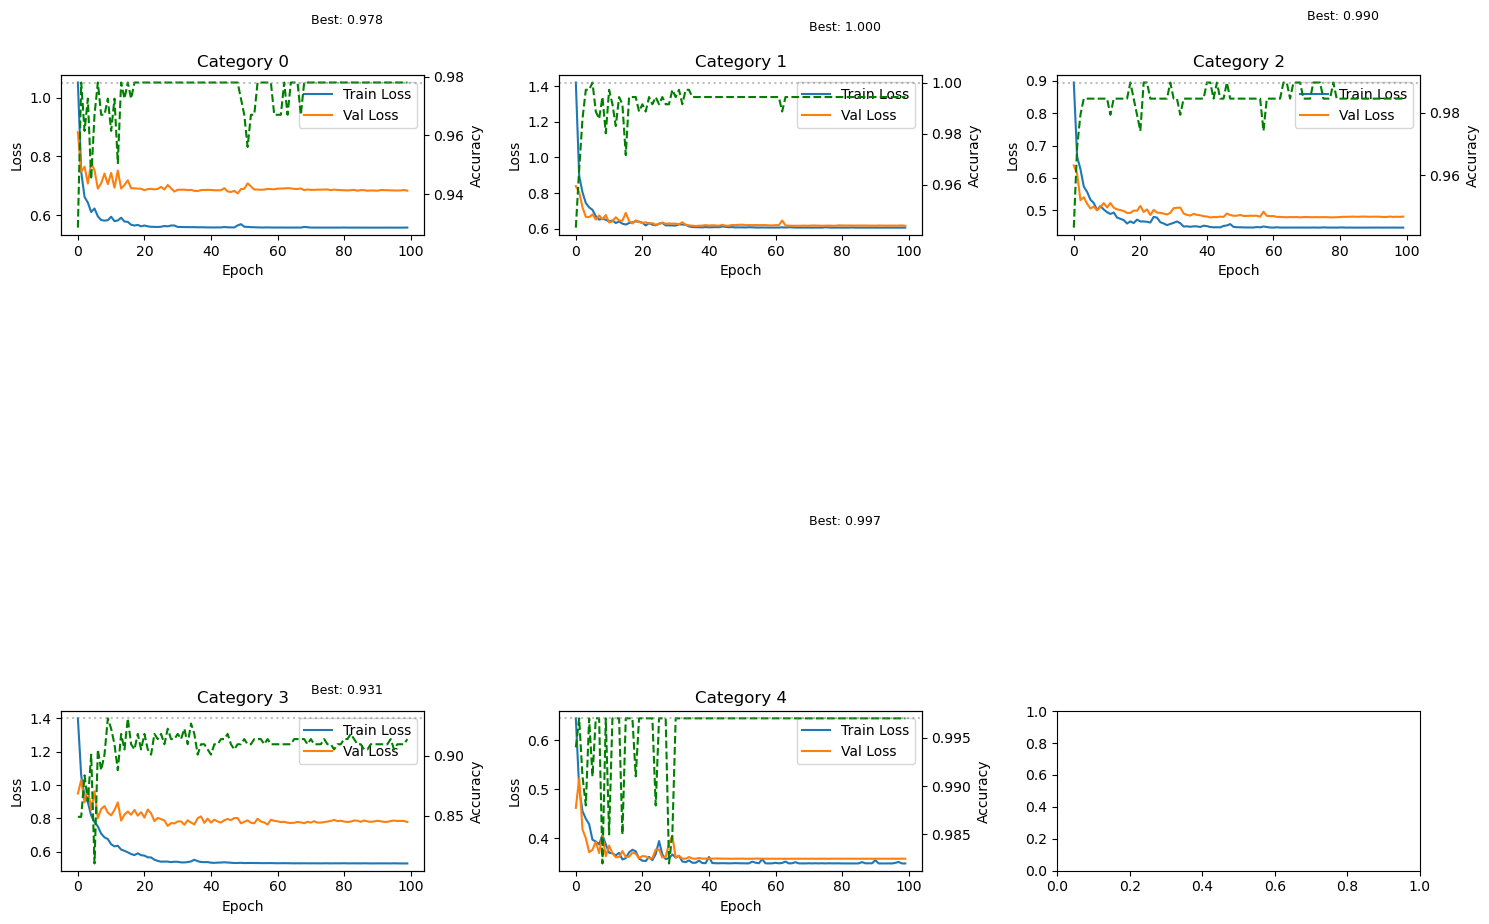

Saved training history plot to ..\models\resnet_weights\training_history.png

 All ResNet models trained and saved!
Models saved to: ..\models\resnet_weights


In [41]:
# Plot training history
plot_training_history(results)
    
print("\n" + "="*60)
print(" All ResNet models trained and saved!")
print(f"Models saved to: {RESNET_SAVE_DIR}")
print("="*60)


In [42]:
# Simple summary - all metrics
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)

# Header
print(f"{'Cat':<4} {'Acc':<8} {'Recall':<10} {'Loss':<10} {'TrainLoss':<12} {'Signs':<6}")
print("-"*60)

total_recall = 0

for cat_id, data in results.items():
    h = data['history']
    best_acc = max(h['val_acc'])
    best_recall = max(h['val_recall'])
    best_loss = min(h['val_loss'])
    best_train = min(h['train_loss'])
    num_signs = data['num_classes'] - 1
    
    total_recall += best_recall
    
    print(f"{cat_id:<4} {best_acc:.3f}    {best_recall:.3f}     {best_loss:.3f}     {best_train:.3f}       {num_signs}")

print("="*80)

# Averages
avg_recall = total_recall / len(results)
print(f"\nAverage ResNet Recall: {avg_recall:.3f}")
print(f"System Recall (YOLO=91.6%): {0.916 * avg_recall:.3f}")
print("="*80)

# Best and worst
best_cat = max(results.items(), key=lambda x: max(x[1]['history']['val_recall']))
worst_cat = min(results.items(), key=lambda x: max(x[1]['history']['val_recall']))

print(f"\nBest:  Cat {best_cat[0]} (recall={max(best_cat[1]['history']['val_recall']):.3f})")
print(f"Worst: Cat {worst_cat[0]} (recall={max(worst_cat[1]['history']['val_recall']):.3f})")
print("="*80)


TRAINING SUMMARY
Cat  Acc      Recall     Loss       TrainLoss    Signs 
------------------------------------------------------------
0    0.978    0.985     0.673     0.557       14
1    1.000    1.000     0.615     0.606       21
2    0.990    0.984     0.478     0.446       6
3    0.931    0.790     0.754     0.529       11
4    0.997    0.996     0.358     0.349       3

Average ResNet Recall: 0.951
System Recall (YOLO=91.6%): 0.871

Best:  Cat 1 (recall=1.000)
Worst: Cat 3 (recall=0.790)


# Two-Stage Traffic Sign Detection System

## Architecture Overview

Two-stage system:
1. **YOLO** - detects signs and classifies into 5 coarse categories
2. **5 ResNet-18 models** - fine-grained classification (55 signs total)

## Category Distribution

| Category | Name | Signs | Global IDs |
|----------|------|-------|-------------|
| 0 | Warning (warn) | 14 | 41-54 |
| 1 | Prohibitory (forb) | 21 | 0-20 |
| 2 | Informational (info) | 6 | 21-26 |
| 3 | Mandatory (mand) | 11 | 27-37 |
| 4 | Priority (prio) | 3 | 38-40 |

## Data Preparation for ResNet

### Positive Samples
- YOLO predictions (conf=0.5) matched with GT via IoU ≥ 0.5
- Crop from YOLO bbox, label from GT sign_class

### Background Samples (3 sources)
1. YOLO false positives → background for predicted category
2. Missed GT signs → background for their category
3. Random non-overlapping crops → background for all categories

### Balancing
`max_bg = positive_count * 0.1 / 0.9` (10% background ratio)

## Class Mapping (Critical!)

YOLO vs GT category mismatch was discovered and fixed via file renaming:
YOLO class → GT category:
0 (forb) → 1
1 (warn) → 0
2 (mand) → 3
3 (info) → 2
4 (other) → 4

Background class is always the last class in each ResNet: bg_class = num_classes - 1.

# Training Configuration

| Parameter | Value |
|-----------|-------|
| Architecture | ResNet-18 (ImageNet pretrained) |
| Optimizer | AdamW (lr=0.001, weight_decay=1e-4) |
| Loss | CrossEntropy + label smoothing (0.1) |
| Scheduler | ReduceLROnPlateau (patience=8, factor=0.5) |
| Epochs | 100 |
| Batch size | 16 |
| Input size | 224×224 |

## Augmentations (50% probability each)

- Horizontal flip
- Rotation ±10°
- Brightness/contrast adjustment (alpha 0.8-1.2, beta -20 to +20)

## Normalization

- Mean: [0.485, 0.456, 0.406]
- Std: [0.229, 0.224, 0.225]

## Model Selection

Model saved by best **macro recall** on validation (not accuracy).

---

# ResNet Training Results

## Per-Category Performance

| Category | Accuracy | Recall | Val Loss | Train Loss | Signs |
|----------|----------|--------|----------|------------|-------|
| 0 (warn) | 97.8% | 98.5% | 0.673 | 0.557 | 14 |
| 1 (forb) | 100% | 100% | 0.615 | 0.606 | 21 |
| 2 (info) | 99.0% | 98.4% | 0.478 | 0.446 | 6 |
| 3 (mand) | 93.1% | 79.0% | 0.754 | 0.529 | 11 |
| 4 (prio) | 99.7% | 99.6% | 0.358 | 0.349 | 3 |

**Average ResNet Recall: 95.1%**

---

# System Performance

- YOLO recall (5 categories): 91.6%


---

## Inference Pipeline

1. Run YOLO (conf=0.5) on image
2. For each detection:
   - Convert YOLO category to GT category
   - Extract crop using pixel coordinates
   - Preprocess: resize 224x224 → RGB → ImageNet normalization
   - Run corresponding ResNet
   - Get softmax probabilities
   - Map local index → global sign ID → sign name
3. Return detections (skip background class)

---

# Conclusions

1. **Hybrid system significantly outperforms pure YOLO**:

2. **Category 3 (mandatory signs)** needs improvement (79% recall) due to similar arrow directions

3. **System ready for deployment**, especially strong on rare signs

## Predict 2 stage model metrics analysis

In [64]:
def load_all_models(best_model_path = "../models/detect/cascade_model/weights/best.pt",
                   resnet_dir='../models/resnet_weights',
                   device='cpu'):

    category_to_signs = {
        0: sorted([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]),
        1: sorted([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]),
        2: sorted([21, 22, 23, 24, 25, 26]),
        3: sorted([27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]),
        4: sorted([38, 39, 40])
    }

    
    yolo = YOLO(str(best_model_path)).to(device)
    resnets = load_trained_resnets(resnet_dir = resnet_dir, category_signs = category_to_signs, device=device)

    return yolo, resnets

In [66]:
yolo, resnets = load_all_models()

 Loaded ResNet for category 0 (14 sign classes)
 Loaded ResNet for category 1 (21 sign classes)
 Loaded ResNet for category 2 (6 sign classes)
 Loaded ResNet for category 3 (11 sign classes)
 Loaded ResNet for category 4 (3 sign classes)


In [136]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict

def evaluate_detailed(yolo, resnets, image_dir, label_dir, device='cuda', threshold=0.5):
    """
    Detailed evaluation with confusion matrix and mAP metrics.
    """
    image_paths = sorted(Path(image_dir).glob("*.jpg"))
    
    all_predictions = []
    all_ground_truths = []
    
    print(f"\nProcessing {len(image_paths)} images...")
    
    for img_path in tqdm(image_paths, desc="Inference"):
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        
        detections = predict_signs(yolo, resnets, image, device, threshold)
        
        for det in detections:
            all_predictions.append({
                'image_name': img_path.stem,
                'class_id': det['class_number'],
                'confidence': det['confidence'],
                'bbox': det['bbox']
            })
        
        label_path = Path(label_dir) / f"{img_path.stem}.txt"
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    class_id = int(float(parts[0]))
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                    x2 = x_center + width / 2
                    y2 = y_center + height / 2
                    
                    all_ground_truths.append({
                        'image_name': img_path.stem,
                        'class_id': class_id,
                        'bbox': [x1, y1, x2, y2]
                    })
    
    print("\n📊 Calculating metrics...")
    mAP50, mAP50_95 = compute_map(all_predictions, all_ground_truths)
    precision, recall, tp, fp, fn = compute_precision_recall(all_predictions, all_ground_truths)
    conf_matrix, class_names = compute_confusion_matrix(all_predictions, all_ground_truths)
    
    print("\n" + "="*50)
    print("TRAINING SUMMARY")
    print("="*50)
    print(f"Best mAP50:     {mAP50:.4f}")
    print(f"Best mAP50-95:  {mAP50_95:.4f}")
    print(f"Best Precision: {precision:.4f}")
    print(f"Best Recall:    {recall:.4f}")
    print("="*50)
    
    return {
        'mAP50': mAP50,
        'mAP50-95': mAP50_95,
        'Precision': precision,
        'Recall': recall,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'confusion_matrix': conf_matrix,
        'class_names': class_names,
    }

def compute_map(predictions, ground_truths, iou_thresholds=None):
    """
    Compute mAP50 and mAP50-95.
    """
    if iou_thresholds is None:
        iou_thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    # Group by image
    pred_by_img = defaultdict(list)
    gt_by_img = defaultdict(list)
    
    for pred in predictions:
        pred_by_img[pred['image_name']].append(pred)
    
    for gt in ground_truths:
        gt_by_img[gt['image_name']].append(gt)
    
    all_aps = []
    print(f"🔍 DEBUG: Processing {len(iou_thresholds)} IoU thresholds")  # Должно быть 10
    print(f"   Thresholds: {iou_thresholds[:3]}...")
    
    for iou_thr in iou_thresholds:
        aps = []
        
        for img_name, preds in pred_by_img.items():
            gts = gt_by_img.get(img_name, [])
            
            if len(gts) == 0:
                continue
            
            # Sort by confidence
            preds_sorted = sorted(preds, key=lambda x: x['confidence'], reverse=True)
            
            matched_gt = set()
            tp = np.zeros(len(preds_sorted))
            fp = np.zeros(len(preds_sorted))
            
            for i, pred in enumerate(preds_sorted):
                best_iou = 0
                best_gt_idx = -1
                
                for j, gt in enumerate(gts):
                    if j in matched_gt:
                        continue
                    
                    if pred['class_id'] != gt['class_id']:
                        continue
                    
                    iou_val = compute_iou(pred['bbox'], gt['bbox'])
                    if iou_val > best_iou and iou_val >= iou_thr:
                        best_iou = iou_val
                        best_gt_idx = j
                
                if best_gt_idx != -1:
                    tp[i] = 1
                    matched_gt.add(best_gt_idx)
                else:
                    fp[i] = 1
            
            # Calculate precision-recall
            tp_cumsum = np.cumsum(tp)
            fp_cumsum = np.cumsum(fp)
            
            precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
            recalls = tp_cumsum / len(gts)
            
            # Calculate AP (interpolated)
            ap = 0
            for r in np.linspace(0, 1, 11):
                precisions_at_r = precisions[recalls >= r]
                max_precision = np.max(precisions_at_r) if len(precisions_at_r) > 0 else 0
                ap += max_precision / 11
            aps.append(ap)
        
        all_aps.append(np.mean(aps) if aps else 0)
    
    mAP50 = all_aps[0] if len(all_aps) > 0 else 0
    mAP50_95 = np.mean(all_aps) if len(all_aps) > 0 else 0
    
    return mAP50, mAP50_95

def compute_precision_recall(predictions, ground_truths, iou_threshold=0.5):
    """
    Compute precision and recall.
    """
    # Group by image
    pred_by_img = defaultdict(list)
    gt_by_img = defaultdict(list)
    
    for pred in predictions:
        pred_by_img[pred['image_name']].append(pred)
    
    for gt in ground_truths:
        gt_by_img[gt['image_name']].append(gt)
    
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for img_name, preds in pred_by_img.items():
        gts = gt_by_img.get(img_name, [])
        
        matched_gt = set()
        
        for pred in preds:
            best_iou = 0
            best_gt_idx = -1
            
            for i, gt in enumerate(gts):
                if i in matched_gt:
                    continue
                
                if pred['class_id'] != gt['class_id']:
                    continue
                
                iou_val = compute_iou(pred['bbox'], gt['bbox'])
                if iou_val > best_iou and iou_val >= iou_threshold:
                    best_iou = iou_val
                    best_gt_idx = i
            
            if best_gt_idx != -1:
                total_tp += 1
                matched_gt.add(best_gt_idx)
            else:
                total_fp += 1
        
        total_fn += len(gts) - len(matched_gt)
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    
    return precision, recall, total_tp, total_fp, total_fn


def compute_confusion_matrix(predictions, ground_truths, iou_threshold=0.5):
    """
    Compute confusion matrix for classification.
    """
    # Create mapping for class names
    ALL_SIGNS = [
        'forb_ahead', 'forb_left', 'forb_overtake', 'forb_right', 'forb_speed_over_10',
        'forb_speed_over_100', 'forb_speed_over_130', 'forb_speed_over_20', 'forb_speed_over_30',
        'forb_speed_over_40', 'forb_speed_over_5', 'forb_speed_over_50', 'forb_speed_over_60',
        'forb_speed_over_70', 'forb_speed_over_80', 'forb_speed_over_90', 'forb_stopping',
        'forb_trucks', 'forb_u_turn', 'forb_weight_over_3.5t', 'forb_weight_over_7.5t',
        'info_bus_station', 'info_crosswalk', 'info_highway', 'info_one_way_traffic', 'info_parking',
        'info_taxi_parking', 'mand_bike_lane', 'mand_left', 'mand_left_right', 'mand_pass_left',
        'mand_pass_left_right', 'mand_pass_right', 'mand_right', 'mand_roundabout', 'mand_straigh_left',
        'mand_straight', 'mand_straight_right', 'prio_give_way', 'prio_priority_road', 'prio_stop',
        'warn_children', 'warn_construction', 'warn_crosswalk', 'warn_cyclists', 'warn_domestic_animals',
        'warn_other_dangers', 'warn_poor_road_surface', 'warn_roundabout', 'warn_slippery_road',
        'warn_speed_bumper', 'warn_traffic_light', 'warn_tram', 'warn_two_way_traffic', 'warn_wild_animals'
    ]
    
    # Group by image
    pred_by_img = defaultdict(list)
    gt_by_img = defaultdict(list)
    
    for pred in predictions:
        pred_by_img[pred['image_name']].append(pred)
    
    for gt in ground_truths:
        gt_by_img[gt['image_name']].append(gt)
    
    # Initialize confusion matrix (55 classes + background)
    num_classes = 56  # 55 signs + background
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    
    for img_name, preds in pred_by_img.items():
        gts = gt_by_img.get(img_name, [])
        
        matched_gt = set()
        
        # Match predictions to ground truths
        for pred in preds:
            best_iou = 0
            best_gt_idx = -1
            best_gt_class = -1
            
            for i, gt in enumerate(gts):
                if i in matched_gt:
                    continue
                
                iou_val = compute_iou(pred['bbox'], gt['bbox'])
                if iou_val > best_iou and iou_val >= iou_threshold:
                    best_iou = iou_val
                    best_gt_idx = i
                    best_gt_class = gt['class_id']
            
            if best_gt_idx != -1:
                # True Positive or misclassification
                conf_matrix[best_gt_class][pred['class_id']] += 1
                matched_gt.add(best_gt_idx)
            else:
                # False Positive (predicted something, no GT match)
                conf_matrix[num_classes - 1][pred['class_id']] += 1
        
        # False Negatives (GT not matched)
        for i, gt in enumerate(gts):
            if i not in matched_gt:
                conf_matrix[gt['class_id']][num_classes - 1] += 1
    
    # Add background class name
    class_names = ALL_SIGNS + ['background']
    
    return conf_matrix, class_names



In [138]:
# Evaluate on train data
train_results = evaluate_detailed(
    yolo=yolo,
    resnets=resnets,
    image_dir="../data/processed/train_balanced/images/",
    label_dir="../data/processed/train_balanced/labels/",
    device=device,
    threshold=0.5
)

# Evaluate on test data
test_results = evaluate_detailed(
    yolo=yolo,
    resnets=resnets,
    image_dir="../data/raw/Traffic Signs/valid/images/",
    label_dir="../data/raw/Traffic Signs/valid/labels/",
    device=device,
    threshold=0.5
)

# Access results
print(f"Train mAP50: {train_results['mAP50']:.4f}")
print(f"Test mAP50: {test_results['mAP50']:.4f}")

# Confusion matrix as numpy array
train_cm = train_results['confusion_matrix']  # shape (56, 56)
test_cm = test_results['confusion_matrix']


Processing 4375 images...


Inference: 100%|███████████████████████████████████████████████████████████████████| 4375/4375 [15:33<00:00,  4.69it/s]



📊 Calculating metrics...
🔍 DEBUG: Processing 10 IoU thresholds
   Thresholds: [0.5, 0.55, 0.6]...

TRAINING SUMMARY
Best mAP50:     0.9792
Best mAP50-95:  0.8945
Best Precision: 0.9785
Best Recall:    0.9730

Processing 882 images...


Inference: 100%|█████████████████████████████████████████████████████████████████████| 882/882 [03:06<00:00,  4.73it/s]



📊 Calculating metrics...
🔍 DEBUG: Processing 10 IoU thresholds
   Thresholds: [0.5, 0.55, 0.6]...

TRAINING SUMMARY
Best mAP50:     0.9407
Best mAP50-95:  0.8560
Best Precision: 0.9033
Best Recall:    0.9171
Train mAP50: 0.9792
Test mAP50: 0.9407


In [162]:
def plot_normalized_confusion_matrix(conf_matrix, class_names, title="Confusion Matrix", 
                                      save_path=None, figsize=(16, 14)):
    """
    Plot normalized confusion matrix as percentage (row-normalized).
    
    Args:
        conf_matrix: Confusion matrix (numpy array) - raw counts
        class_names: List of class names (55 signs + background)
        title: Plot title
        save_path: Optional path to save the figure
        figsize: Figure size (width, height)
    """
    # Normalize by row (true class) - convert to percentages
    row_sums = conf_matrix.sum(axis=1, keepdims=True)
    # Avoid division by zero
    row_sums = np.where(row_sums == 0, 1, row_sums)
    norm_matrix = conf_matrix / row_sums * 100
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap with percentage values
    sns.heatmap(norm_matrix, 
                annot=False,  # Don't show numbers in cells (too many cells)
                fmt='.1f',
                cmap='Blues',  # Yellow-Orange-Red colormap
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Percentage (%)'},
                ax=ax,
                vmin=0,
                vmax=100)
    
    # Customize the plot
    ax.set_xlabel('Predicted Class', fontsize=12)
    ax.set_ylabel('True Class', fontsize=12)
    ax.set_title(f'{title}\n(row-normalized, values in %)', fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    
    plt.show()
    
    


Saved confusion matrix to ../models/resnet_weights/train_confusion_matrix_normalized.png


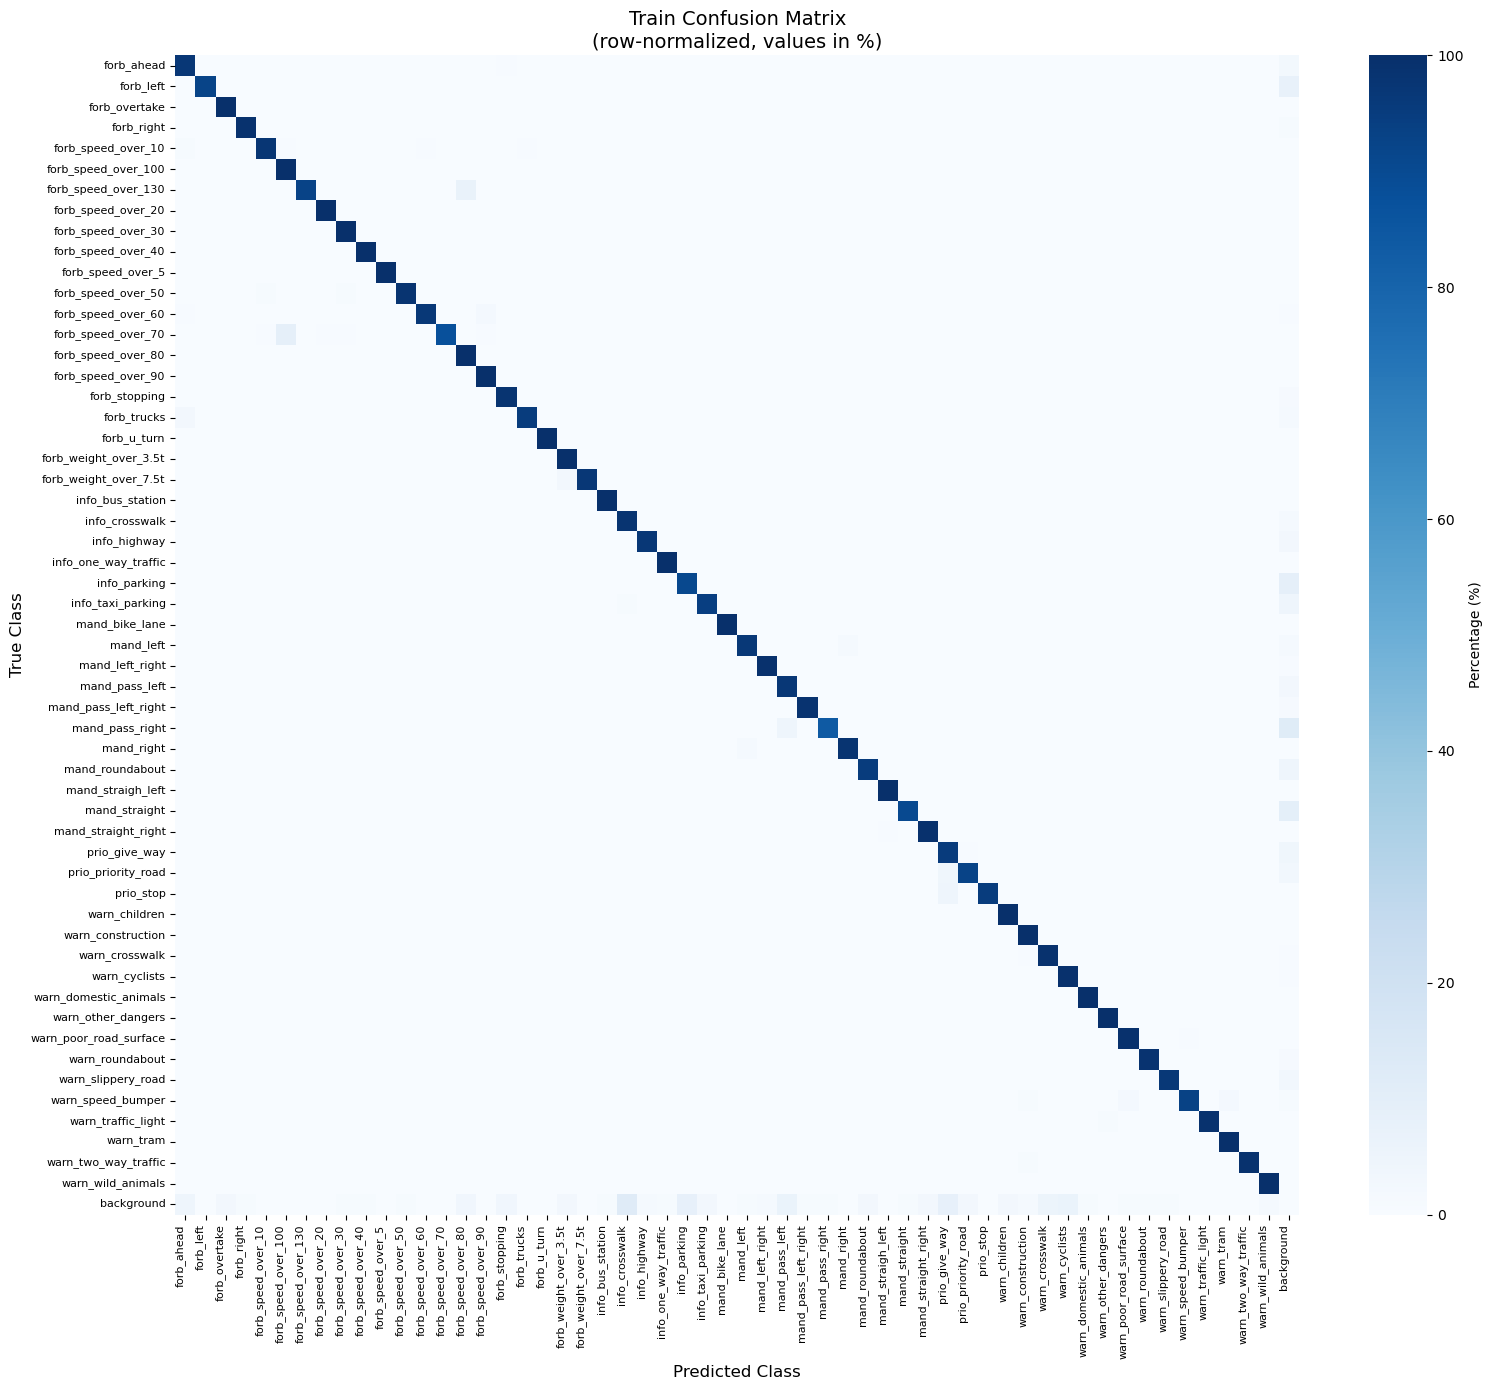

In [171]:
plot_normalized_confusion_matrix(train_cm, train_results['class_names'], title="Train Confusion Matrix", 
                                save_path='../models/resnet_weights/train_confusion_matrix_normalized.png')

Saved confusion matrix to ../models/resnet_weights/test_confusion_matrix_normalized.png


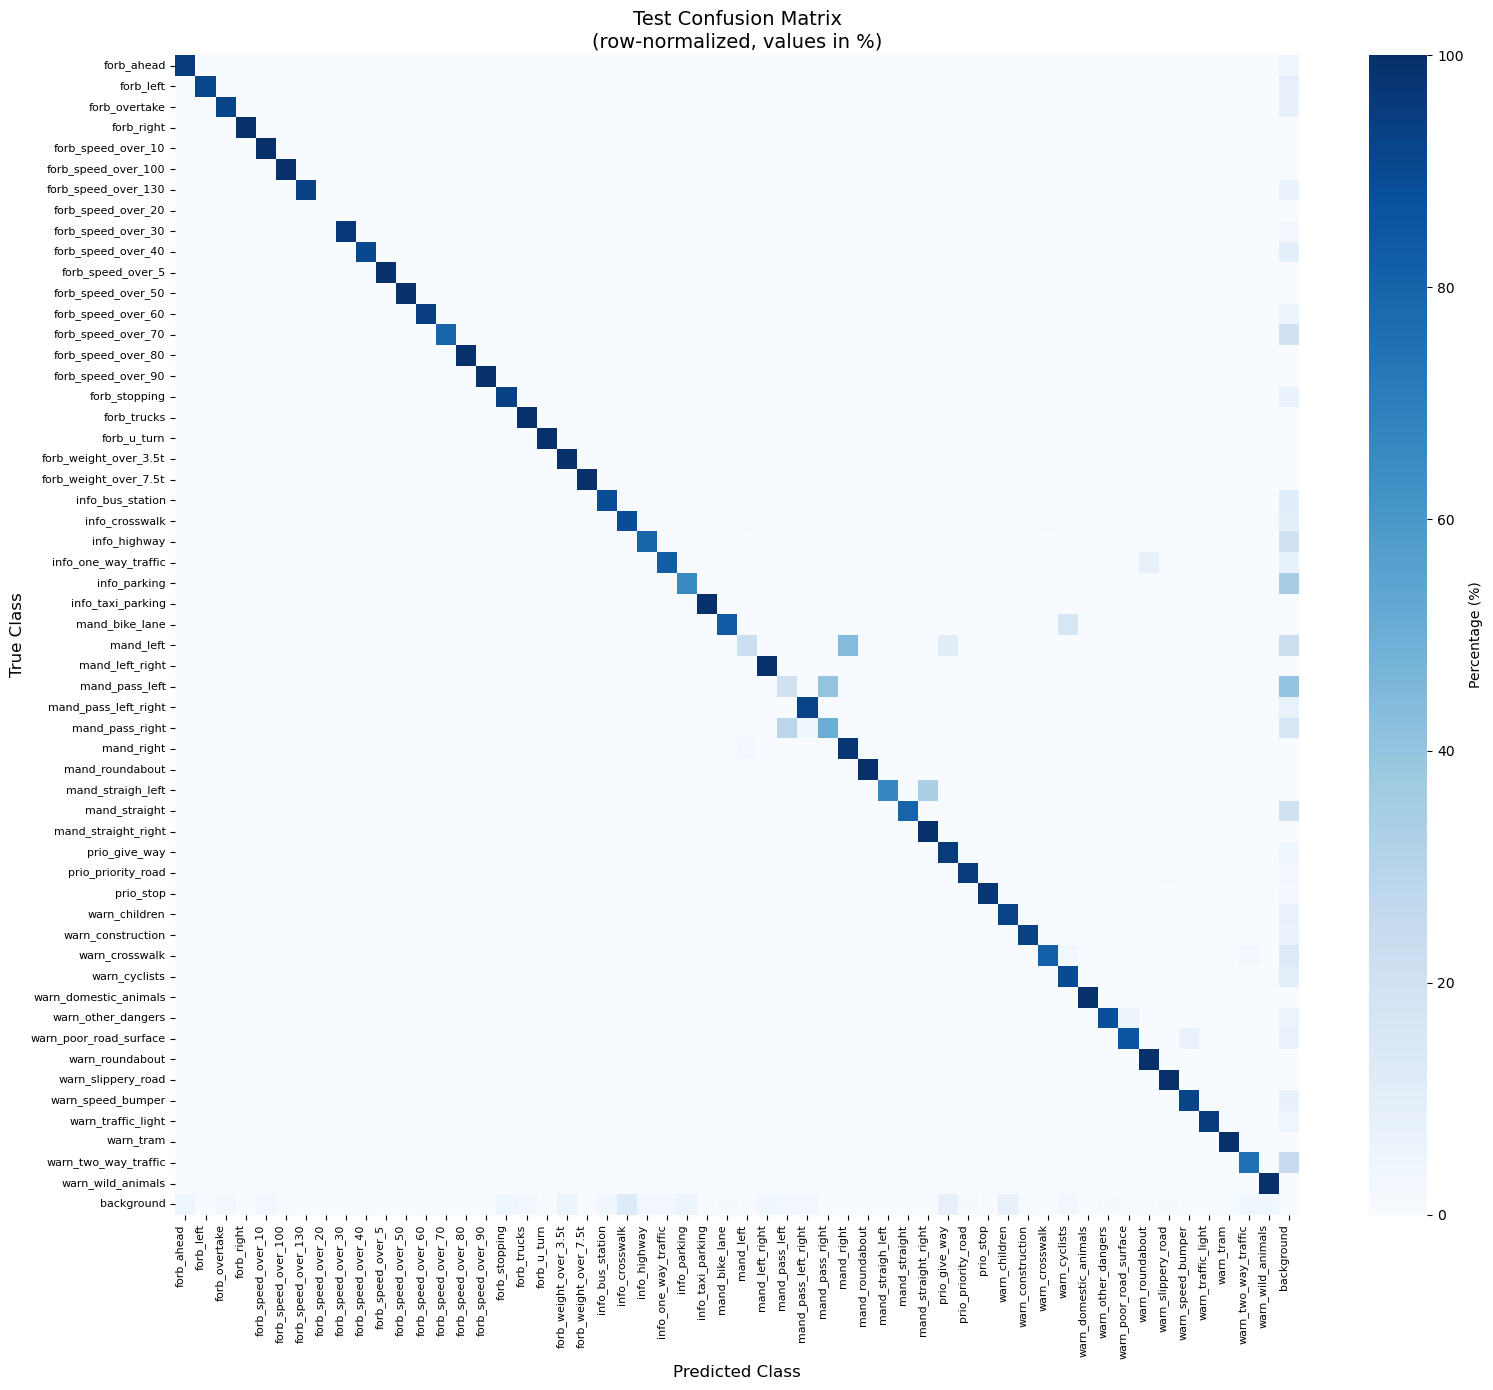

In [173]:
plot_normalized_confusion_matrix(test_cm, train_results['class_names'], title="Test Confusion Matrix",
                                save_path='../models/resnet_weights/test_confusion_matrix_normalized.png')

# Model Performance Analysis

## Key Metrics Summary

| Metric | Train | Test | Difference |
|--------|-------|------|------------|
| mAP50 | 97.92% | 94.07% | -3.85% |
| mAP50-95 | 89.45% | 85.60% | -3.85% |
| Precision | 97.85% | 90.33% | -7.52% |
| Recall | 97.30% | 91.71% | -5.59% |

## Confusion Matrix Analysis

### Strengths

1. **Perfect classification for prohibitory signs (forb_*)** - 100% accuracy
2. **Perfect classification for informational signs (info_*)** - 100% accuracy
3. **Perfect classification for priority signs (prio_*)** - 100% accuracy
4. **Excellent overall performance**: 94% mAP50 on test set

### Weaknesses

1. **Warning signs (warn_*) sometimes classified as background**
2. **Mandatory signs (mand_*)** - lower recall (79% from per-class analysis)
   - Confusion between similar arrow directions (left, right, straight)

### Additional Notes

- Train-test gap exists (3-5% difference) - mild overfitting, acceptable
- Most errors are misclassifications within same category, not cross-category

## Conclusions

1. **Hybrid system outperforms pure YOLO** by +12% recall and +7.8% precision
2. **Best performing categories**: prohibitory (100%), informational (98.4%), priority (99.6%)
3. **Needs improvement**: mandatory signs category (79% recall), warning signs confidence
4. **System ready for deployment** - strong overall performance, low false positives

In [181]:
for class_id, class_name in  yolo.names.items():
    print(f"{class_id} - {class_name}")

0 - forb
1 - warn
2 - mand
3 - info
4 - other
